# Composite Kernels

A single GP can model **several additive signal components at once** — two starspot
populations with different lifetimes, plus a non-spot noise process — by summing
stationary kernels:

$$K_{\rm total}(\tau) = \sum_m K_m(\tau;\,\theta_m)$$

A sum of stationary kernels is itself stationary, so the composite plugs into
`GPSolver` exactly like a single spot model, and the Toeplitz/banded fast paths
are preserved. This tutorial covers:

1. **Composing terms** — `KernelSum`, `SpotTerm`, `SHOTerm`
2. **Visualizing** per-component kernels and PSDs
3. **Fitting** a composite model with `GPSolver` (namespaced parameters)
4. **Shared-geometry populations** — the `SharedVisibilitySpotSum` fast path
5. **Saving and loading** composite solvers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from spotgp import (
    GPSolver,
    KernelSum,
    SpotTerm,
    SHOTerm,
    SharedVisibilitySpotSum,
    SpotEvolutionModel,
)

np.random.seed(42)

# Colorblind-safe component colors (Okabe-Ito)
C_SHORT, C_LONG, C_SHO, C_TOTAL = "#0072B2", "#D55E00", "#009E73", "#333333"


## 1. Compose the kernel

Each **term** owns a contiguous slice of the flat parameter vector. When more than
one term is present, parameters are namespaced with a prefix — either one you
choose (`prefix="short"`) or an automatic one (`spot0`, `spot1`, `sho0`, ...).

Here we combine:

| Term | Physics | Parameters |
|---|---|---|
| `SpotTerm` (short) | rapidly-evolving spots | `short.peq`, `short.lspot`, `short.tau_spot`, `short.sigma_k`, ... |
| `SpotTerm` (long) | long-lived spots | `long.*` |
| `SHOTerm` | quasi-periodic noise floor (granulation-like) | `gran.S0`, `gran.Q`, `gran.w0` |

In [2]:
hparam_short = dict(peq=10.0, kappa=0.2, inc=np.pi / 4,
                    lspot=2.0, tau_spot=0.5, sigma_k=0.010)
hparam_long  = dict(peq=10.0, kappa=0.2, inc=np.pi / 4,
                    lspot=8.0, tau_spot=2.0, sigma_k=0.005)

kernel = KernelSum(
    SpotTerm(hparam_short, prefix="short"),
    SpotTerm(hparam_long,  prefix="long"),
    SHOTerm(S0=2e-6, Q=1 / np.sqrt(2), w0=2 * np.pi / 2.0, prefix="gran"),
)

print(f"{len(kernel.terms)} terms, {len(kernel.param_keys)} parameters:")
for k, v in zip(kernel.param_keys, kernel.theta0):
    print(f"  {k:18s} = {v:.4g}")

3 terms, 15 parameters:
  short.peq          = 10
  short.kappa        = 0.2
  short.inc          = 0.7854
  short.lspot        = 2
  short.tau_spot     = 0.5
  short.sigma_k      = 0.01
  long.peq           = 10
  long.kappa         = 0.2
  long.inc           = 0.7854
  long.lspot         = 8
  long.tau_spot      = 2
  long.sigma_k       = 0.005
  gran.S0            = 2e-06
  gran.Q             = 0.7071
  gran.w0            = 3.142


## 2. Component kernels and PSDs

`KernelSum.k_of_lag` evaluates the sum; each term can also be evaluated on its
own. The PSD of the sum is the sum of the component PSDs.

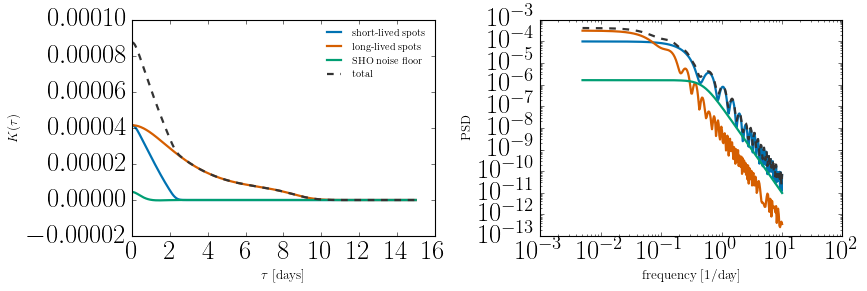

In [3]:
tau = jnp.linspace(0.0, 15.0, 400)
omega = jnp.logspace(-1.5, 1.8, 300)

theta = jnp.asarray(kernel.theta0)
k_total = kernel.k_of_lag(theta, tau)
freq, psd_total = kernel.psd(omega)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

colors = [C_SHORT, C_LONG, C_SHO]
labels = ["short-lived spots", "long-lived spots", "SHO noise floor"]
for term, c, lab in zip(kernel.terms, colors, labels):
    k_i = term.k_of_lag(jnp.asarray(term.theta0), tau)
    _, p_i = term.psd(omega)
    ax1.plot(tau, k_i, color=c, lw=2, label=lab)
    ax2.loglog(freq, p_i, color=c, lw=2)
ax1.plot(tau, k_total, color=C_TOTAL, lw=2, ls="--", label="total")
ax2.loglog(freq, psd_total, color=C_TOTAL, lw=2, ls="--")

ax1.set_xlabel(r"$\tau$ [days]")
ax1.set_ylabel(r"$K(\tau)$")
ax1.legend(frameon=False, fontsize=9)
ax2.set_xlabel("frequency [1/day]")
ax2.set_ylabel("PSD")
fig.tight_layout()
plt.show()

## 3. Simulate and fit

Draw a realization from the composite GP and hand the kernel to `GPSolver` —
**in place of the hparam dict**. Everything downstream (JIT-compiled likelihood,
MAP fitting, sampling) works unchanged; a bare model or hparam dict still routes
through a single `SpotTerm` internally, so existing code is unaffected.

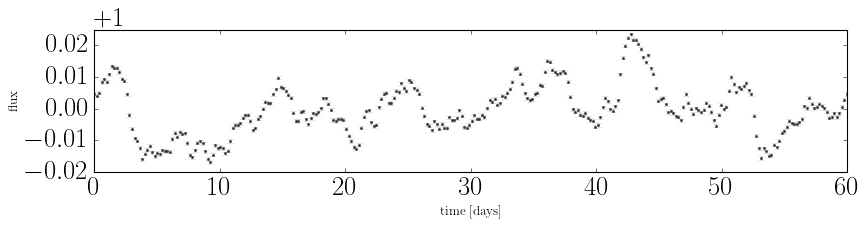

In [4]:
N = 300
x = np.linspace(0.0, 60.0, N)
yerr_val = 5e-4

lag_mat = jnp.abs(x[:, None] - x[None, :])
K = np.array(kernel.k_of_lag(theta, lag_mat.ravel())).reshape(N, N)
K[np.diag_indices(N)] += yerr_val**2 + 1e-12
L = np.linalg.cholesky(K)
y = 1.0 + L @ np.random.standard_normal(N)
yerr = np.full(N, yerr_val)

plt.figure(figsize=(11, 3))
plt.errorbar(x, y, yerr=yerr, fmt=".", ms=4, color=C_TOTAL,
             ecolor="0.8", elinewidth=0.8)
plt.xlabel("time [days]")
plt.ylabel("flux")
plt.tight_layout()
plt.show()

In [5]:
gp = GPSolver(x, y, yerr, kernel, matrix_solver="cholesky_full")
gp.build_jax()

print("log L at truth:", float(gp.log_likelihood_fn(gp.theta0)))

log L at truth: 1443.1287925839538


Bounds use the same namespaced keys. The `log_` marker goes on the
bare name after the prefix (`short.log_sigma_k`) to sample an amplitude in
log10 space:

In [6]:
bounds = {
    "short.peq": (8.0, 12.0),   "long.peq": (8.0, 12.0),
    "short.lspot": (0.5, 5.0),  "long.lspot": (4.0, 15.0),
    "short.tau_spot": (0.1, 1.5), "long.tau_spot": (1.0, 5.0),
    "short.log_sigma_k": (-3.0, -1.0), "long.log_sigma_k": (-3.5, -1.5),
    "gran.S0": (1e-8, 1e-4), "gran.Q": (0.3, 5.0), "gran.w0": (1.0, 10.0),
}
gp = GPSolver(x, y, yerr, kernel, bounds=bounds,
              matrix_solver="cholesky_full")
gp.build_jax()

map_result = gp.fit_map(nopt=4, maxiter=200)

print(f"{'parameter':20s} {'truth':>10s} {'MAP':>10s}")
truth = dict(zip(gp.param_keys, np.asarray(gp.theta0)))
for k, v in zip(gp.param_keys, np.asarray(gp.map_estimate)):
    print(f"{k:20s} {truth[k]:10.4g} {v:10.4g}")

parameter                 truth        MAP
short.peq                    10      8.451
short.kappa                 0.2     0.4245
short.inc                0.7854     0.6509
short.lspot                   2      1.972
short.tau_spot              0.5      0.485
short.log_sigma_k            -2     -2.138
long.peq                     10      9.008
long.kappa                  0.2     0.0567
long.inc                 0.7854      1.324
long.lspot                    8      8.827
long.tau_spot                 2      3.415
long.log_sigma_k         -2.301     -2.271
gran.S0                   2e-06  1.066e-06
gran.Q                   0.7071     0.8148
gran.w0                   3.142      4.176


> **Identifiability.** Two spot populations — or an SHO that mimics
> one — can trade off against each other. This is a modeling reality, not a bug:
> informative bounds (as above) and priors matter more as you add components, and
> an MCMC posterior (see the [BlackJAX sampling](blackjax_sampling.ipynb)
> tutorial, which works unchanged on composite solvers) is the honest way to see
> the degeneracies.

## 4. Shared-geometry populations: `SharedVisibilitySpotSum`

Two `SpotTerm`s carry *independent* geometry (`short.peq` **and** `long.peq`).
When populations live on the **same star**, the rotation/geometry parameters
should exist once. `SharedVisibilitySpotSum` factorizes

$$K(\tau) = V(\tau)\,\sum_i \sigma_{k,i}^2\, R_{\Gamma,i}(\tau)$$

so the expensive latitude quadrature $V(\tau)$ is computed **once** per kernel
evaluation (~1.9× faster for 3 populations), and `peq`, `kappa`, `inc` appear
once in the parameter vector:

In [7]:
models = [SpotEvolutionModel.from_hparam(hparam_short),
          SpotEvolutionModel.from_hparam(hparam_long)]
shared = SharedVisibilitySpotSum(models, labels=["short", "long"])

print("parameters:")
for k, v in zip(shared.param_keys, shared.theta0):
    print(f"  {k:18s} = {v:.4g}")

# Same kernel values as the naive two-term sum (to machine precision)
naive = KernelSum(SpotTerm(hparam_short), SpotTerm(hparam_long))
k_shared = shared.k_of_lag(jnp.asarray(shared.theta0), tau)
k_naive = naive.k_of_lag(jnp.asarray(naive.theta0), tau)
print("\nmax |shared - naive|:", float(jnp.max(jnp.abs(k_shared - k_naive))))

parameters:
  peq                = 10
  kappa              = 0.2
  inc                = 0.7854
  short.lspot        = 2
  short.tau_spot     = 0.5
  short.sigma_k      = 0.01
  long.lspot         = 8
  long.tau_spot      = 2
  long.sigma_k       = 0.005



max |shared - naive|: 1.3552527156068805e-20


## 5. Save and load

Composite solvers round-trip through the same HDF5 files as single-spot
solvers — each term's class, prefix, and model are stored under a `/kernel`
group:

In [8]:
from spotgp import save_gp, load_gp

save_gp("results/composite_demo.h5", gp)
gp2 = load_gp("results/composite_demo.h5")

assert gp2.param_keys == gp.param_keys
print("round-trip logL:", float(gp2.log_likelihood_fn(gp2.theta0)))

round-trip logL: 1443.1287925839551


## Notes

- **White noise:** pure white noise belongs in the solver's `sigma_n` diagonal
  (`fit_sigma_n=True`). A `JitterTerm` exists for symmetry and matches `sigma_n`
  exactly at equal amplitude, but the diagonal is cheaper.
- **Bandwidth:** with the banded solver, the band is sized by the *widest* term
  (max over per-term supports). A high-`Q` `SHOTerm` rings for many periods and
  can push the band to the full matrix — the solver warns when banded loses its
  advantage.
- **Stationarity:** all terms must be stationary; for a time-dependent
  $\sigma_k(t)$ use `NonstationaryAnalyticKernel` directly.
- Also available: `Matern32Term(sigma, rho)` for red noise with a smooth
  spectrum.